## 1. Initial checking

In [20]:
import numpy as np
import mmcfilters
import matplotlib
import math

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (16, 16)

from IPython import display
from os import listdir
import cv2 as cv

import mmcfilters

In [21]:
imgInput = cv.imread("../dat/imgTeste.png", cv.IMREAD_GRAYSCALE)

(num_rows, num_cols) = imgInput.shape

In [22]:
AT = mmcfilters.Attribute.Type
tree = mmcfilters.MorphologicalTree(imgInput)
mmcfilters.Attribute.computeSingleAttribute(tree, AT.MAX_DIST)

array([3769., 3161., 8992.,    0.,    0., 1570.,  900.,  144.,    0.,    0.], dtype=float32)

## 2. Simple image checking

### 2.1 Importing library and defining plotting functions

In [23]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import mmcfilters 
import pandas as pd
import math

from IPython import display
np.set_printoptions(suppress=True, threshold=np.inf, linewidth=np.inf, precision=2)

from PrettyPrint import PrettyPrintTree
from colorama import Fore, Back

def printSimpleTree():
    printTree = PrettyPrintTree(
        lambda node: node.children,
        lambda node: f"ID:{node.id}\nLevel: {node.level}\n|cnps|: {len(node.cnps)}\nArea: {node.area}",
        color=Back.BLACK + Fore.WHITE,
    )
    return printTree

def printTreeWithAttribute(attrType, attrValue):
    printTree = PrettyPrintTree(
        lambda node: node.children,
        lambda node: f"ID: {node.id},\nLevel: {node.level}\n|cnps|: {len(node.cnps)}\nArea: {node.area}\n{attrType.name}: {attrValue[node.id]}",
        color=Back.BLACK + Fore.WHITE
    )
    return printTree

def showLevelSets(img_f):
    print("Upper and lower level sets where in black are foreground and white are background pixels")
    t_values = np.unique(img_f)
    len = np.size(t_values)
    print(len)
    max_value = np.max(img_f)
    fig, axes = plt.subplots(len, 2, figsize=(5, 15))

    # Filling the subplots with threshold images
    for i, t in enumerate(t_values):
        # first column: img_f >= t
        thr = t_values[i]
        img_threshold_ge = np.where(img_f >= thr, 1, 0)
        axes[i, 0].imshow(img_threshold_ge, cmap="gray_r", vmax=1, vmin=0, interpolation="nearest")
        axes[i, 0].set_title(f"image >= {t}")
        axes[i, 0].axis("off")
        axes[i, 0].add_patch(plt.Rectangle((0, 0), img_threshold_ge.shape[1] - 1, img_threshold_ge.shape[0]-1,
                                    edgecolor="blue", linewidth=0.5, fill=False))

        # second column: img <= t
        thr = t_values[len - i - 1]
        img_threshold_le = np.where(img_f <= thr, 1, 0)
        axes[i, 1].imshow(img_threshold_le, cmap="gray", vmax=1, vmin=0, interpolation="nearest")
        axes[i, 1].set_title(f"image <= {thr}")
        axes[i, 1].axis("off")
        axes[i, 1].add_patch(plt.Rectangle((0, 0), img_threshold_le.shape[1] - 1, img_threshold_le.shape[0] - 1,
                                    edgecolor="blue", linewidth=0.5, fill=False))

    # adjust layout for avoiding superposition 
    plt.tight_layout()
    plt.show()


def showTree(tree, printTree=printSimpleTree()):
    if (tree.treeType == 0):
        print("Image and its max-tree representation. The indices of the max-tree nodes are shown as labels in the image.")
    elif (tree.treeType == 1):
        print("Image and its min-tree representation. The indices of the min-tree nodes are shown as labels in the image.")
    else:
        print("Image and its tree of shapes representation. The indices of the tree of shapes are shown as labels in the image.")

    img_vector = tree.reconstructionImage()
    ids_position = []

    for node in tree.root.postOrderTraversal():
        px, py = computeCentroid(node.cnps)
        ids_position.append((node.id, px, py))
        
    # plot image
    plt.figure(figsize=(8, 6))
    image = img_vector.reshape(tree.numRows, tree.numCols)
    # Adding a border around the image
    ax = plt.gca()
    ax.add_patch(plt.Rectangle((0,0), image.shape[1] - 1, image.shape[0] - 1, edgecolor="red", linewidth=0.5, fill=False))
    plt.imshow(image, cmap="gray")

    # Add labels at the false centroids
    for i, (id, x, y) in enumerate(ids_position):
        plt.text(y, x, f"•{id}", color="red", fontsize=9)

    plt.axis("off")
    plt.show()
    printTree(tree.root)



def computeCentroid(cnps):
    closest_pixel = cnps[len(cnps)//2]
    px, py = closest_pixel // num_cols, closest_pixel % num_cols
    return px, py

def showNode(node):
    image = node.recNode().reshape(num_rows, num_cols)
    ax = plt.gca()  # obtain the current axis
    ax.imshow(image, cmap="gray")
    ax.add_patch(plt.Rectangle((0,0), image.shape[1] - 1, image.shape[0] - 1, edgecolor="red", linewidth=0.5, fill=False))
    ax.set_title(f"{node}")
    ax.axis("off")

def buildMapIds(tree):
    mapIds  = np.zeros(num_rows * num_cols)
    for p in range(num_rows * num_cols):
        mapIds[p] = tree.getSC(p).id
    return mapIds

In [24]:
from importlib.metadata import version
print("Installed version:", version("mmcfilters"))

Installed version: 0.1.24.post8


### 2.2 Creating the morphological tree of an input image

Upper and lower level sets where in black are foreground and white are background pixels
10


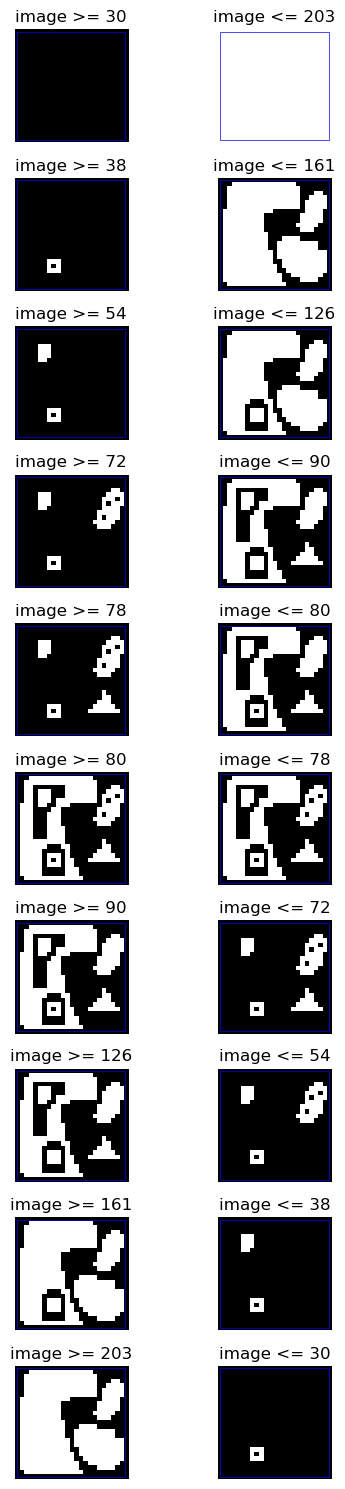




Image and its max-tree representation. The indices of the max-tree nodes are shown as labels in the image.


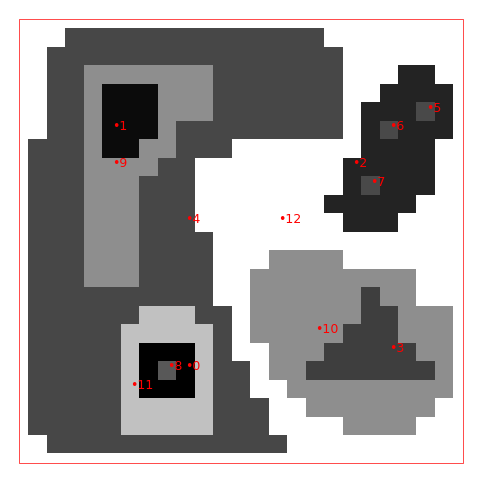

                                                          ID:0      
                                                          Level: 30 
                                                          |cnps|: 8 
                                                          Area: 625 
                                           ┌──────────────────┴──────────────────┐
                                       ID:1                                  ID:8      
                                       Level: 38                             Level: 90 
                                       |cnps|: 11                            |cnps|: 1 
                                       Area: 616                             Area: 1   
                                           |                                           
                                       ID:2                                            
                                       Level: 54                                       
                         

In [25]:
imgInput = np.array([
        [203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203],
        [203,203,203, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78,203,203,203,203,203,203,203,203],
        [203,203, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78,203,203,203,203,203,203,203],
        [203,203, 78, 78,126,126,126,126,126,126,126, 78, 78, 78, 78, 78, 78, 78,203,203,203, 54, 54,203,203],
        [203,203, 78, 78,126, 38, 38, 38,126,126,126, 78, 78, 78, 78, 78, 78, 78,203,203, 54, 54, 54, 54,203],
        [203,203, 78, 78,126, 38, 38, 38,126,126,126, 78, 78, 78, 78, 78, 78, 78,203, 54, 54, 54, 80, 54,203],
        [203,203, 78, 78,126, 38, 38, 38,126, 78, 78, 78, 78, 78, 78, 78, 78, 78,203, 54, 80, 54, 54, 54,203],
        [203, 78, 78, 78,126, 38, 38,126,126, 78, 78, 78,203,203,203,203,203,203,203, 54, 54, 54, 54,203,203],
        [203, 78, 78, 78,126,126,126,126, 78, 78,203,203,203,203,203,203,203,203, 54, 54, 54, 54, 54,203,203],
        [203, 78, 78, 78,126,126,126, 78, 78, 78,203,203,203,203,203,203,203,203, 54, 80, 54, 54, 54,203,203],
        [203, 78, 78, 78,126,126,126, 78, 78, 78,203,203,203,203,203,203,203, 54, 54, 54, 54, 54,203,203,203],
        [203, 78, 78, 78,126,126,126, 78, 78, 78,203,203,203,203,203,203,203,203, 54, 54, 54,203,203,203,203],
        [203, 78, 78, 78,126,126,126, 78, 78, 78, 78,203,203,203,203,203,203,203,203,203,203,203,203,203,203],
        [203, 78, 78, 78,126,126,126, 78, 78, 78, 78,203,203,203,126,126,126,126,203,203,203,203,203,203,203],
        [203, 78, 78, 78,126,126,126, 78, 78, 78, 78,203,203,126,126,126,126,126,126,126,126,126,203,203,203],
        [203, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78,203,203,126,126,126,126,126,126, 72,126,126,203,203,203],
        [203, 78, 78, 78, 78, 78, 78,161,161,161, 78, 78,203,126,126,126,126,126,126, 72, 72,126,126,126,203],
        [203, 78, 78, 78, 78, 78,161,161,161,161,161, 78,203,126,126,126,126,126, 72, 72, 72,126,126,126,203],
        [203, 78, 78, 78, 78, 78,161, 30, 30, 30,161, 78,203,203,126,126,126, 72, 72, 72, 72, 72,126,126,203],
        [203, 78, 78, 78, 78, 78,161, 30, 90, 30,161, 78, 78,203,126,126, 72, 72, 72, 72, 72, 72, 72,126,203],
        [203, 78, 78, 78, 78, 78,161, 30, 30, 30,161, 78, 78,203,203,126,126,126,126,126,126,126,126,126,203],
        [203, 78, 78, 78, 78, 78,161,161,161,161,161, 78, 78, 78,203,203,126,126,126,126,126,126,126,203,203],
        [203, 78, 78, 78, 78, 78,161,161,161,161,161, 78, 78, 78,203,203,203,203,126,126,126,126,203,203,203],
        [203,203, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78,203,203,203,203,203,203,203,203,203,203],
        [203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203]
], dtype=np.uint8)

(num_rows, num_cols) = imgInput.shape

isMaxtree = True
tree = mmcfilters.MorphologicalTree(imgInput, isMaxtree)
Type = mmcfilters.Attribute.Type

showLevelSets(imgInput)
print("\n\n")
showTree(tree)

## 3. Visualise Max-Dist

In [26]:
Type = mmcfilters.Attribute.Type

attrType = Type.MAX_DIST
attrValue = mmcfilters.Attribute.computeSingleAttribute(tree, attrType)

print(f"{attrType.name} (numpy): {attrValue}")

MAX_DIST (numpy): [292. 292. 290.  36.  29.   0.   0.   0.   0.   1.  10.   0.   5.]


Image and its max-tree representation. The indices of the max-tree nodes are shown as labels in the image.


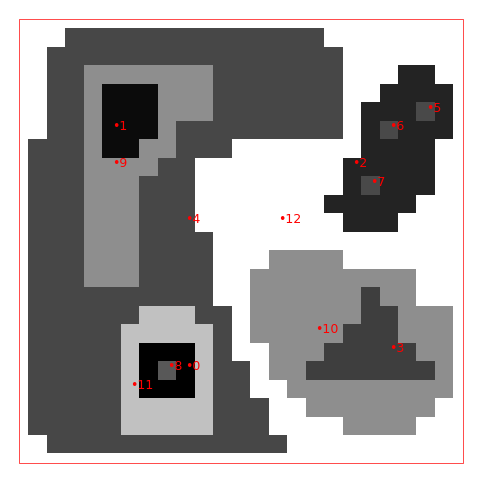

                                                                        ID: 0,          
                                                                        Level: 30       
                                                                        |cnps|: 8       
                                                                        Area: 625       
                                                                        MAX_DIST: 292.0 
                                                       ┌───────────────────────┴────────────────────────┐
                                                ID: 1,                                            ID: 8,        
                                                Level: 38                                         Level: 90     
                                                |cnps|: 11                                        |cnps|: 1     
                                                Area: 616                                         Area: 1     

In [27]:
showTree(tree, printTreeWithAttribute(attrType, attrValue))

(25, 25)


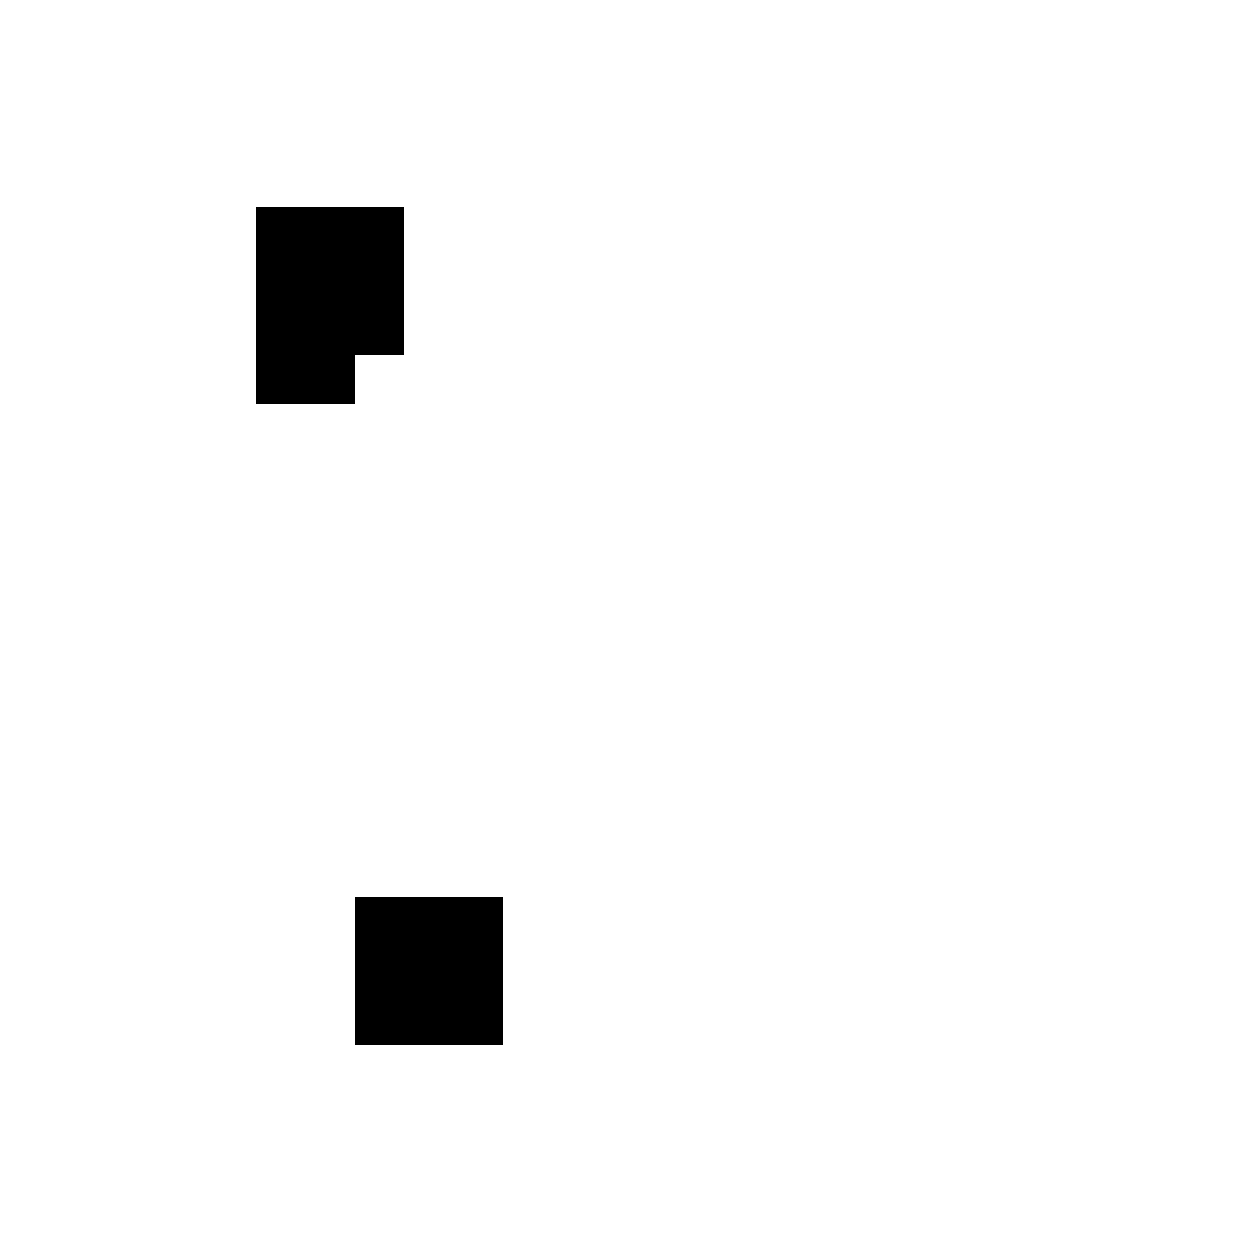

In [30]:
nodeImg = tree.listNodes[2].recNode().reshape(imgInput.shape)

print(nodeImg.shape)

plt.imshow(nodeImg, cmap="gray")
plt.axis("off")
plt.show()

cv.imsave(

# 5. Extinction values in the synthetic image

uint8


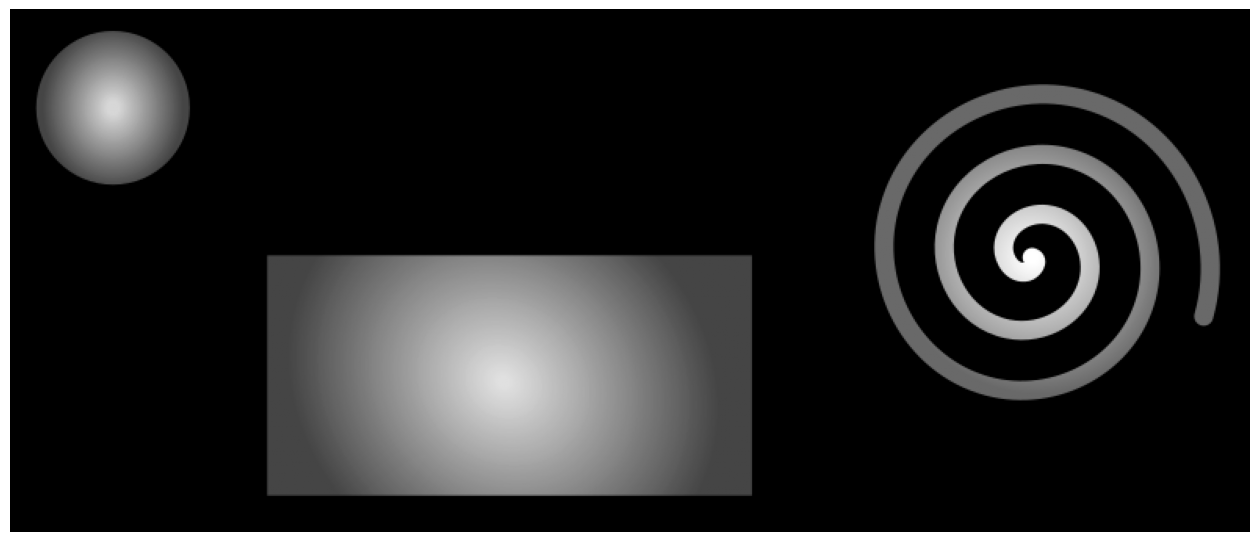

In [68]:
f = cv.imread("../dat/maxdist-test.png", cv2.IMREAD_GRAYSCALE)

print(f.dtype)

plt.imshow(f, cmap="gray")
plt.axis("off")
plt.show()

In [76]:
tree = mmcfilters.MorphologicalTree(f, isMaxtree=True)
maxdist = mmcfilters.Attribute.computeSingleAttribute(tree, Type.MAX_DIST)

exval = mmcfilters.ExtinctionValues(tree, maxdist)

for (leaf, cutoffNode, extinction) in exval.getExtinctionValues():
    print(f"leaf: {leaf}")
    print(f"extinction value: {extinction}")
    print(f"cuttoff: {cutoffNode}")

leaf: NodeMT(id=585, level=215, numCNPs=56, area=56)
extinction value: 9140.0
cuttoff: NodeMT(id=1, level=1, numCNPs=10, area=7730)
leaf: NodeMT(id=635, level=255, numCNPs=59, area=59)
extinction value: 53.0
cuttoff: NodeMT(id=2, level=1, numCNPs=82, area=14875)
leaf: NodeMT(id=605, level=224, numCNPs=54, area=54)
extinction value: 0.0
cuttoff: NodeMT(id=0, level=0, numCNPs=194183, area=264528)


In [75]:
print(len(tree.leaves))
print(tree.treeType)

3
0


# 4. Extinction value filter in the cable images

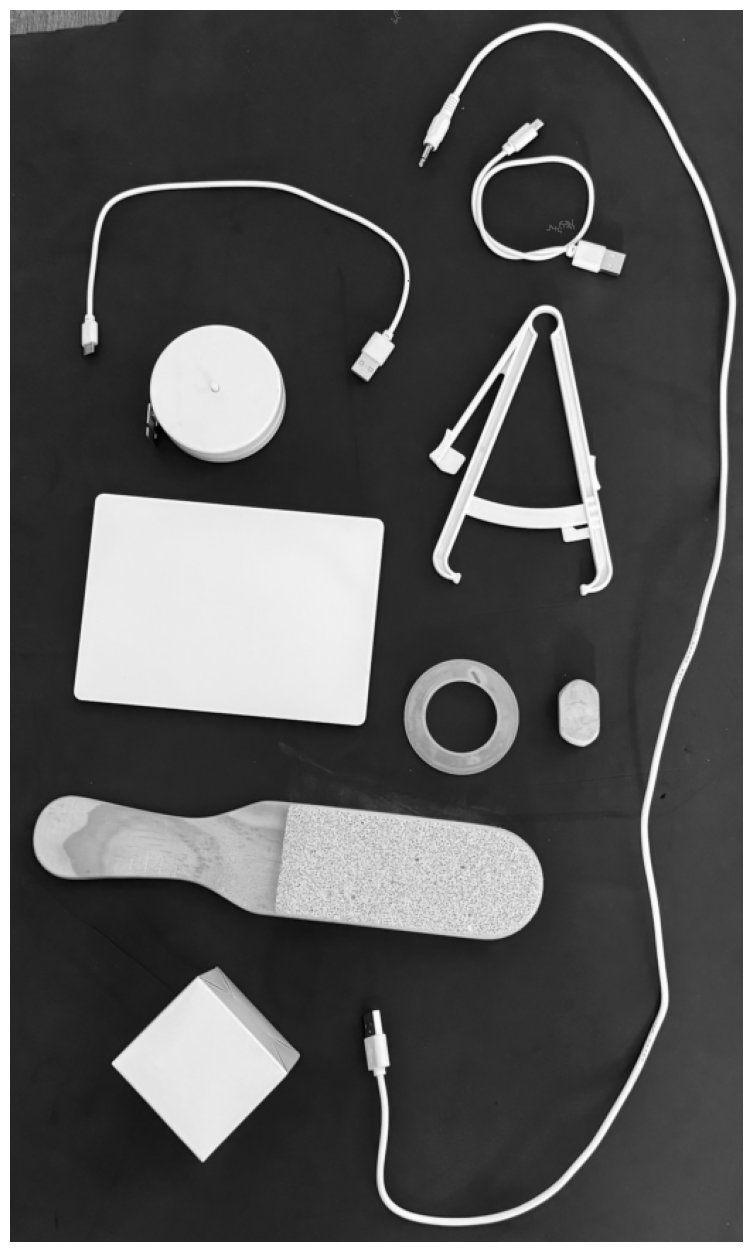

In [37]:
import cv2 

f = cv2.imread("../dat/imgObjetos.png", cv2.IMREAD_GRAYSCALE)

plt.imshow(f, cmap="gray")
plt.axis("off")
plt.show()

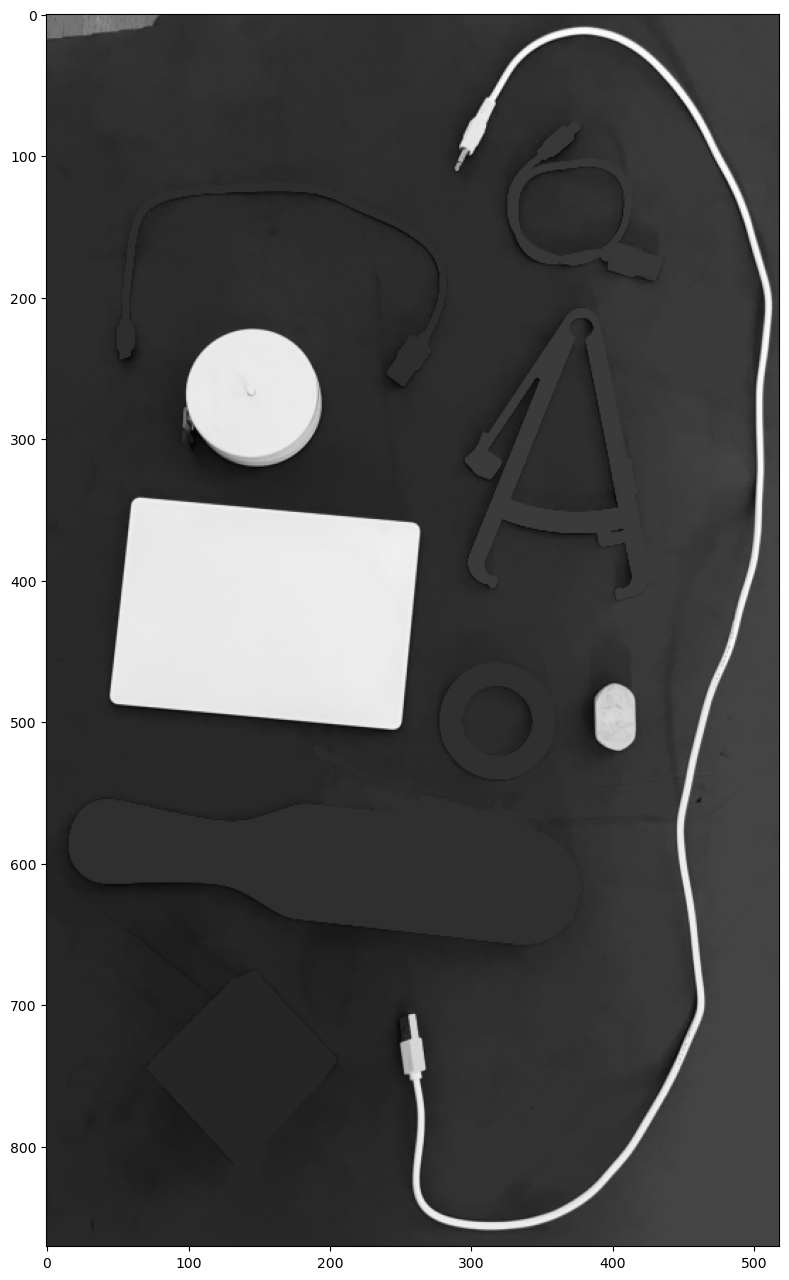

In [61]:
tree_f = mmcfilters.MorphologicalTree(f, isMaxtree=True)

maxdist = mmcfilters.Attribute.computeSingleAttribute(tree_f, Type.MAX_DIST)
extinctionValues = mmcfilters.ExtinctionValues(tree_f, maxdist)


f_final = mmcfilters.A
plt.imshow(img_final, cmap="gray", vmax=255, vmin=0)
plt.show()